In [9]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.1 MB 1.2 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.1 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.1 MB 970.7 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.1 MB 970.7 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.1 MB 997.6 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 1.0 MB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.1 MB 986.2 kB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.1 MB 986.2 kB/s eta 0:00:07
   ----------- --------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Persamaan Eliptik

Persamaan eliptik berdimensi lebih tinggi secara umum memiliki bentuk
$$ a_1u_{xx}+a_2u_{xy}+a_3u_{yy}+a_4u_x+a_5u_y+a_6u=f $$
dengan syarat koefisien harus memenuhi
$$ a_2^2-4a_1a_3<0. $$




Salah satu tempat alami di mana persamaan seperti ini muncul kembali adalah pada masalah keadaan tunak (steady-state) yang berasal dari persamaan panas.
Dalam dua dimensi kita punya
$$ u_t=(\kappa u_x)_x+(\kappa u_y)_y+\Psi (x,y). $$
dengan:
- $ u(x,y,t)$ = suhu sebagai fungsi ruang dan waktu,
- $ \kappa $  = konduktivitas termal,
- $ \Psi (x,y) $ = sumber panas.

Jika keadaan tunak berarti suhu tidak berubah terhadap waktu, sehingga:
 $ u_t=0$, maka kita memperoleh 
$$ (\kappa u_x)_x+(\kappa u_y)_y=-\Psi (x,y). $$



Jika kita mengasumsikan $\kappa$  konstan, maka kita dapat menuliskan ulang persamaan ini sebagai
$$ u_{xx}+u_{yy}=-\frac{\Psi }{\kappa }=f(x,y), $$
yang merupakan bentuk berdimensi lebih tinggi dari persamaan Poisson (dan persamaan Laplace jika $$ f(x,y)=0). $$
Kita juga harus menentukan suatu domain $\Omega$  serta kondisi batas seperti sebelumnya.



## 5-Point Stencil
Ekstensi dari pekerjaan kita dalam satu dimensi ke dua dimensi memungkinkan kita membangun 5-point stencil untuk operator Laplasian sebagai berikut
$$ \nabla ^2u\approx \frac{U_{i-1,j}-2U_{i,j}+U_{i+1,j}}{\Delta x^2}+\frac{U_{i,j-1}-2U_{i,j}+U_{i,j+1}}{\Delta y^2}. $$



Jika $$ \Delta x=\Delta y, $$ kita dapat menyederhanakan ekspresi ini menjadi
$$ \nabla ^2u\approx \frac{U_{i-1,j}+U_{i+1,j}-4U_{i,j}+U_{i,j-1}+U_{i,j+1}}{\Delta x^2}. $$



Kita dapat menghampiri solusi dari persamaan Poisson sebagai
$$ \frac{U_{i-1,j}+U_{i+1,j}-4U_{i,j}+U_{i,j-1}+U_{i,j+1}}{\Delta x^2}=f_{i,j}, $$
yang menghasilkan $ m^2 $ persamaan untuk $ m^2 $ variabel tak diketahui.


## Pengurutan Variabel Tak Diketahui

Kita dapat membayangkan masalah dua dimensi kita sebagai terletak pada sebuah grid seperti pada gambar berikut.
Di sini, variabel tak diketahui ditandai dengan warna merah dan batas-batas ditandai dengan warna biru :
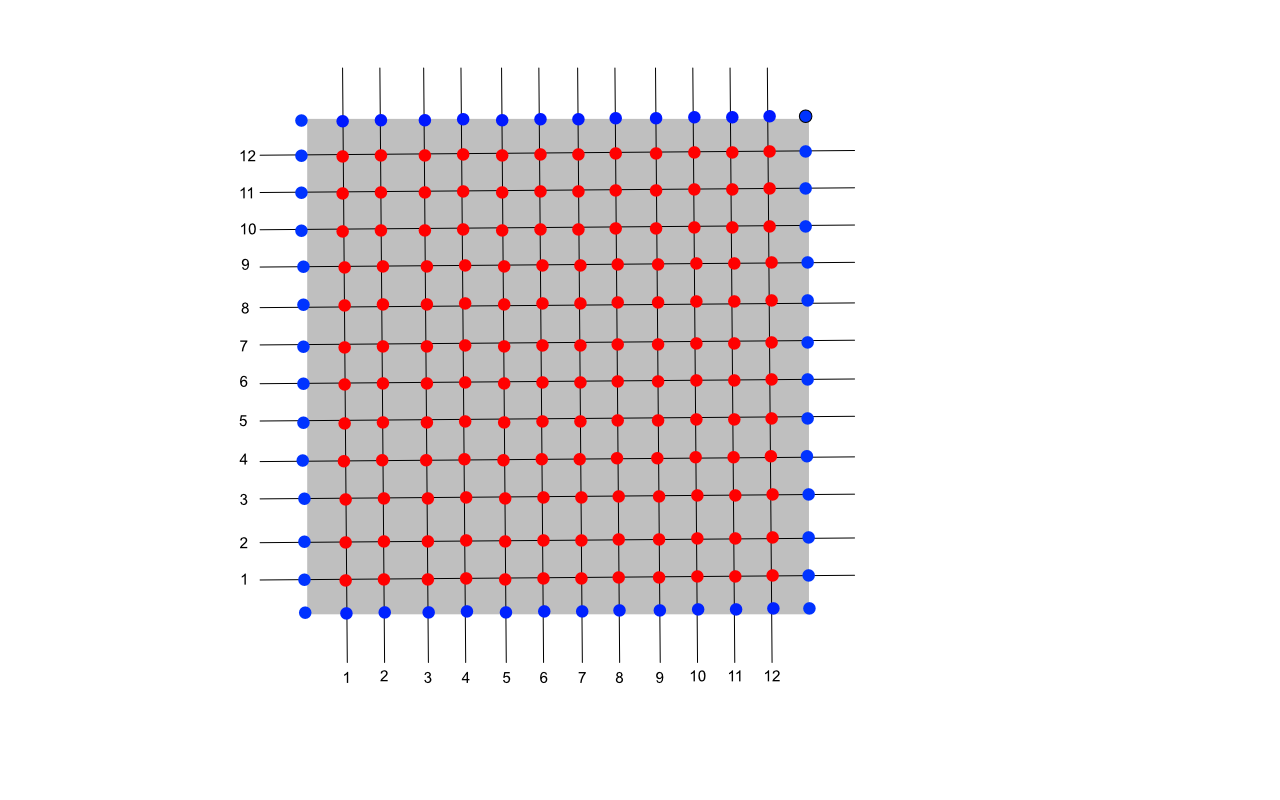

Kita dapat memandang grid sebagai sebuah matriks seperti
$$ U=\left[ \begin{matrix}U_{1,m}&U_{2,m}&\cdots &U_{m-1,m}&U_{m,m}\\ U_{1,m-1}&U_{2,m-1}&\cdots &U_{m-1,m-1}&U_{m,m-1}\\ \vdots &&&&\vdots \\ U_{1,2}&U_{2,2}&\cdots &U_{m-1,2}&U_{m,2}\\ U_{1,1}&U_{2,1}&\cdots &U_{m-1,1}&U_{m,1}\\ \end{matrix}\right] $$
Penting untuk dicatat bahwa pelabelan ini tidak sesuai dengan notasi matriks yang biasa kita gunakan!


Ketika kita berada pada satu dimensi, pengurutan variabel tak diketahui (dan persamaan) cukup jelas, tetapi sekarang kita memiliki beberapa pilihan yang harus dibuat.
Mungkin pilihan yang paling jelas adalah memecah array 2D menjadi baris-baris, lalu menambahkan setiap baris ke akhir baris sebelumnya. Hal ini menghasilkan pengurutan:
$$ U=[U_{1,1},U_{2,1},\ldots ,U_{m-1,1},U_{m,1},U_{1,2},U_{2,2},\ldots ,U_{m-1,m},U_{m,m}] $$
Coba lihat apakah kamu dapat menemukan struktur matriks A sekarang dengan pengurutan ini.


Hal ini menghasilkan sebuah matriks dengan bentuk
$$ A=\frac{1}{\Delta x^2}\left[ \begin{matrix}T&I\\ I&T&I\\ &I&T&I\\ &&\ddots &\ddots &\ddots \\ &&&I&T&I\\ &&&&I&T\end{matrix}\right] $$
di mana matriks T adalah
$$ T=\left[ \begin{matrix}-4&1\\ 1&-4&1\\ &1&-4&1\\ &&\ddots &\ddots &\ddots \\ &&&1&-4&1\\ &&&&1&-4\end{matrix}\right] $$
dan I adalah matriks identitas berukuran $ m\times m. $


Kemungkinan lain adalah pengurutan red-black (seperti papan catur).
Di sini kita “memberi warna” pada setiap variabel tak diketahui dalam grid secara bergantian, lalu setiap variabel yang memiliki warna sama dikelompokkan bersama.

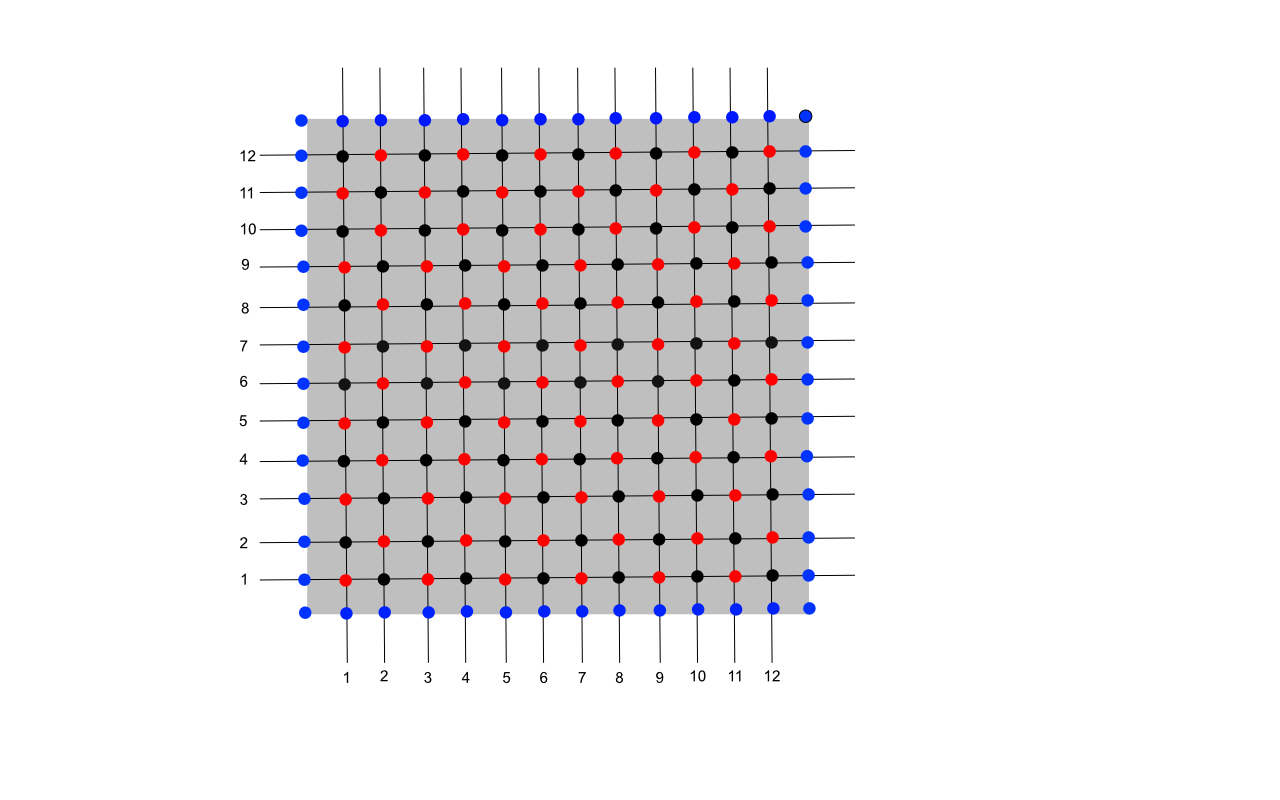

Bisakah kamu membayangkan seperti apa bentuk matriks dalam kasus ini?

Untuk pengurutan red-black kita memperoleh matriks dengan bentuk
$$ \left[ \begin{matrix}D&H\\ H^T&D\end{matrix}\right] \left[ \begin{matrix}U_{\mathrm{red}}\\ U_{\mathrm{black}}\end{matrix}\right] =\left[ \begin{matrix}f_{\mathrm{red}}\\ f_{\mathrm{black}}\end{matrix}\right] $$
Di sini , sebuah matriks diagonal berdimensi $ m^2/2 $ , dan $ H $ adalah banded matrix dengan 4 diagonal tak nol.
Biasanya tujuan dari pengurutan adalah untuk membuat jarak antar elemen tak nol sekecil mungkin dan mengurangi jumlah fill-in ketika menyelesaikan sistem menggunakan, misalnya, eliminasi Gauss. Hal ini sering ditangani secara otomatis ketika menggunakan rutin penyelesaian yang canggih.


Selesaikan PDE berikut dengan pengurutan yang kamu pilih:
$$ \nabla ^2u=-2\sin x\sin y\quad \Omega =[0,2\pi ]\times [0,2\pi ]
u(x,0)=0,\quad u(x,2\pi )=0,\quad u(0,y)=0,\quad u(2\pi ,y)=0. $$



In [7]:
import scipy

In [10]:
import numpy

0.0012900074949949803


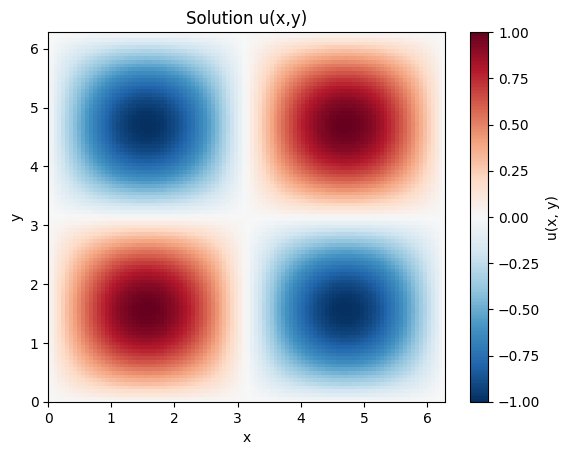

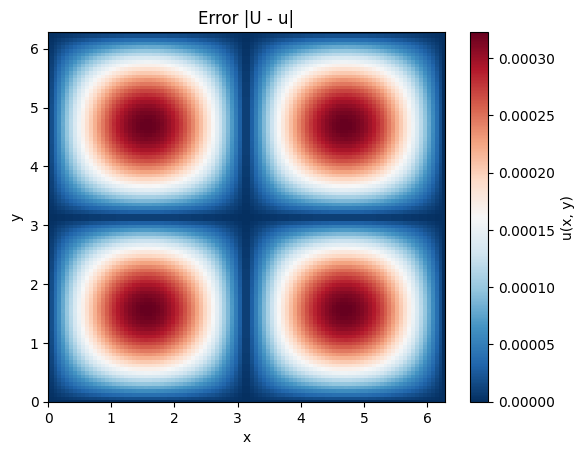

In [5]:
import scipy.sparse as sparse        # Mengimpor modul matriks sparse (jarang terisi)
import scipy.sparse.linalg as linalg # Mengimpor solver aljabar linear untuk matriks sparse

# Problem specification
m = 100                               # Jumlah titik grid interior pada arah x dan y
x = numpy.linspace(0, 2.0 * numpy.pi, m + 2)  # Membuat grid x dari 0 sampai 2π (termasuk batas)
y = numpy.linspace(0, 2.0 * numpy.pi, m + 2)  # Membuat grid y dari 0 sampai 2π
delta_x = 2.0 * numpy.pi / (m + 1)             # Jarak antar grid (Δx)

# Construct A
e = numpy.ones(m)                     # Vektor berisi angka 1 sebanyak m elemen
T = sparse.spdiags([e, -4.0 * e, e], [-1, 0, 1], m, m)  
# Matriks tridiagonal untuk operator Laplacian arah x

S = sparse.spdiags([e, e], [-1, 1], m, m)      
# Matriks yang merepresentasikan interaksi grid tetangga atas dan bawah

I = sparse.eye(m)                     # Matriks identitas ukuran m x m

A = sparse.kron(I, T) + sparse.kron(S, I)      
# Membentuk matriks Laplacian 2D menggunakan produk Kronecker

A /= delta_x**2                       # Membagi matriks dengan (Δx²) sesuai diskretisasi PDE

# Right-hand-side
X, Y = numpy.meshgrid(x[1:-1], y[1:-1])  
# Membuat grid 2D tanpa titik batas

f = -2.0 * numpy.sin(X) * numpy.sin(Y)  
# Fungsi sumber f(x,y) dari persamaan Poisson

# Solve
U = numpy.zeros((m+2, m+2))          
# Matriks solusi awal (termasuk batas)

U[1:-1, 1:-1] = linalg.spsolve(A, f.reshape(m**2, order='F')).reshape((m, m), order='F')
# Menyelesaikan sistem linear A*u = f
# reshape digunakan untuk mengubah matriks menjadi vektor dan sebaliknya

# Error
X, Y = numpy.meshgrid(x, y)          
# Membuat grid lengkap termasuk batas

print(numpy.linalg.norm((x[1] - x[0]) * (U - numpy.sin(X) * numpy.sin(Y)), ord=1))
# Menghitung error antara solusi numerik dan solusi eksak
# menggunakan norma L1

# Plot solution
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

sol_plot = axes.pcolor(X, Y, U, cmap=plt.get_cmap('RdBu_r'))
# Membuat plot warna (heatmap) dari solusi numerik U

axes.set_title("Solution u(x,y)")    
axes.set_xlabel("x")
axes.set_ylabel("y")

axes.set_xlim((0.0, 2.0 * numpy.pi))
axes.set_ylim((0.0, 2.0 * numpy.pi))
# Mengatur batas sumbu plot

cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("u(x, y)")
# Menambahkan colorbar untuk menunjukkan nilai solusi

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

sol_plot = axes.pcolor(X, Y, numpy.abs(U - numpy.sin(X) * numpy.sin(Y)), cmap=plt.get_cmap('RdBu_r'))
# Plot error absolut antara solusi numerik dan solusi eksak

axes.set_title("Error |U - u|")
axes.set_xlabel("x")
axes.set_ylabel("y")

axes.set_xlim((0.0, 2.0 * numpy.pi))
axes.set_ylim((0.0, 2.0 * numpy.pi))

cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("u(x, y)")

plt.show()  
# Menampilkan semua plot

In [2]:
import numpy

In [4]:
import matplotlib.pyplot as plt

## Akurasi dan Stabilitas

Tentu saja kita dapat (dan seharusnya) mengajukan pertanyaan yang sama seperti pada kasus satu dimensi, yaitu apakah skema kita akan konvergen. Untuk melakukan ini kita perlu mempertimbangkan LTE dan stabilitas metode kita.

Kita tahu bahwa LTE didefinisikan sebagai
$$\begin{aligned}
    \tau_{ij} &= \frac{1}{\Delta x^2} (u(x_{i-1}, y_{j}) + u(x_{i+1}, y_{j}) + u(x_{i}, y_{j-1}) + u(x_{i}, y_{j+1}) - 4 u(x_{i}, y_{j})) - f(x_i, y_j)
\end{aligned}$$

Untuk menghitung ekspresi ini kita memerlukan deret Taylor pada setiap arah.”
Untuk arah x:
$$ \begin{aligned}u(x_{i+1},y_j)&=u(x_i,y_j)+\Delta x\, u(x_i,y_j)_x+\frac{\Delta x^2}{2}u(x_i,y_j)_{xx}+\frac{\Delta x^3}{6}u(x_i,y_j)_{xxx}+\frac{\Delta x^4}{24}u(x_i,y_j)_{xxxx}+\mathcal{O}(\Delta x^5)\\ u(x_{i-1},y_j)&=u(x_i,y_j)-\Delta x\, u(x_i,y_j)_x+\frac{\Delta x^2}{2}u(x_i,y_j)_{xx}-\frac{\Delta x^3}{6}u(x_i,y_j)_{xxx}+\frac{\Delta x^4}{24}u(x_i,y_j)_{xxxx}+\mathcal{O}(\Delta x^5)\end{aligned} $$
Untuk arah y:
$$ \begin{aligned}u(x_i,y_{j+1})&=u(x_i,y_j)+\Delta y\, u(x_i,y_j)_y+\frac{\Delta y^2}{2}u(x_i,y_j)_{yy}+\frac{\Delta y^3}{6}u(x_i,y_j)_{yyy}+\frac{\Delta y^4}{24}u(x_i,y_j)_{yyyy}+\mathcal{O}(\Delta y^5)\\ u(x_i,y_{j-1})&=u(x_i,y_j)-\Delta y\, u(x_i,y_j)_y+\frac{\Delta y^2}{2}u(x_i,y_j)_{yy}-\frac{\Delta y^3}{6}u(x_i,y_j)_{yyy}+\frac{\Delta y^4}{24}u(x_i,y_j)_{yyyy}+\mathcal{O}(\Delta y^5)\end{aligned} $$


Dengan menggunakan juga deret Taylor pada arah y, kita dapat menuliskan LTE sebagai
$$ \tau _{ij}=\frac{1}{12}\Delta x^2\, (u_{xxxx}+u_{yyyy})+\mathcal{O}(\Delta x^4). $$


Sistem linear untuk LTE kemudian memiliki bentuk
$$ A_{\Delta x}E_{\Delta x}=-\tau _{\Delta x} $$
di mana sekarang $ A $ adalah diskretisasi yang telah kita tulis sebelumnya. Perlu dicatat bahwa pengurutan persamaan tidak berpengaruh ketika mempertimbangkan kesalahan.


Untuk stabilitas dalam norma-2 kita sekali lagi dapat mempertimbangkan nilai eigen dari sistem di atas. Nilai eigen tersebut adalah
$$ \lambda _{pq}=\frac{2}{\Delta x^2}\left( (\cos (p\pi \Delta x)-1)+(\cos (q\pi \Delta x)-1)\right) $$
dengan vektor eigen yang bersesuaian
$$ v_{ij}^{p,q}=\sin (p\pi i\Delta x)\sin (q\pi j\Delta x). $$


Karena nilai eigen semuanya bernilai negatif (A pada kenyataannya adalah negative definite), maka nilai eigen yang paling dekat dengan titik asal adalah
$$ \lambda _{11}=-2\pi ^2+\mathcal{O}(\Delta x^2) $$
yang menghasilkan jari-jari spektral

Kita dapat menggunakan batas ini pada $ A^{-1} $ untuk menunjukkan stabilitas dan dengan demikian konvergensi dari diskretisasi.


Sebuah kuantitas serupa dan berguna untuk dipertimbangkan adalah bilangan kondisi dari matriks A. Ingat bahwa ini dapat didefinisikan sebagai
$$ \kappa (A)=\| A\| \, \| A^{-1}\| $$


Dalam norma-2 kita sudah mengetahui beberapa informasi tentang $$ A^{-1}, $$ tetapi kita juga dapat menggunakan ekspresi dari atas untuk menemukan jari-jari spektral dari A. Nilai eigen terbesar di sana adalah
$$ \lambda _{mm}\approx -\frac{8}{\Delta x^2} $$
yang menghasilkan bilangan kondisi
$$ \kappa _2(A)=\frac{4}{\pi ^2\Delta x^2}=\mathcal{O}\left( \frac{1}{\Delta x^2}\right) $$
Maka matriks ini menjadi semakin ill-conditioned ketika \Delta x\rightarrow 0.


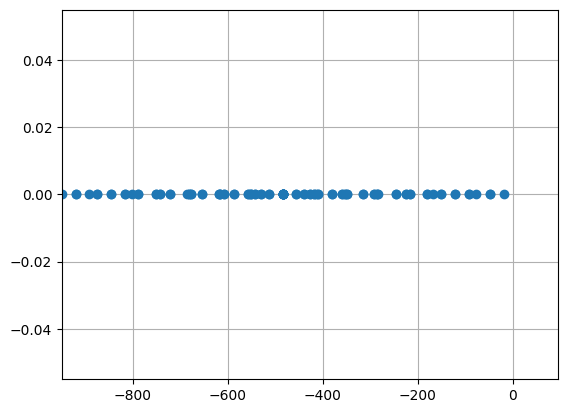

In [6]:
# Compute the eigenvalues
# Menghitung nilai eigen (eigenvalues)

m = 10  
# jumlah titik grid internal pada satu arah (x dan y)

delta_x = 1.0 / float(m + 1)  
# jarak antar titik grid (grid spacing)

eig_vals = numpy.empty(m**2)  
# membuat array kosong untuk menyimpan m^2 nilai eigen

for (i, p) in enumerate(numpy.arange(1, m + 1)):  
# loop untuk indeks p dari 1 sampai m
# enumerate digunakan agar kita mendapatkan indeks i sekaligus nilainya

    for (j, q) in enumerate(numpy.arange(1, m + 1)):  
    # loop kedua untuk indeks q dari 1 sampai m

        eig_vals[i * m + j] = 2.0 / delta_x**2 * (
            (numpy.cos(p * numpy.pi * delta_x) - 1.0) +
            (numpy.cos(q * numpy.pi * delta_x) - 1.0)
        )
        # rumus nilai eigen untuk operator Laplacian diskrit 2D
        # menggunakan metode beda hingga (finite difference)
        # nilai eigen disimpan dalam array eig_vals


# Plot of the eigenvalues of the 5-point Laplacian
# Membuat grafik nilai eigen dari operator Laplacian 5-titik

fig = plt.figure()  
# membuat objek figure untuk plot

axes = fig.add_subplot(1, 1, 1)  
# membuat satu subplot dalam figure

axes.plot(eig_vals.real, eig_vals.imag, 'o')  
# memplot nilai eigen
# sumbu x = bagian real
# sumbu y = bagian imajiner
# 'o' berarti titik-titik lingkaran

axes.grid(True)  
# menampilkan grid pada grafik

axes.set_xlim(numpy.amin(eig_vals), -numpy.amin(eig_vals) * 0.1)  
# mengatur batas sumbu x berdasarkan nilai eigen minimum

plt.show()  
# menampilkan grafik

## Laplasian 9-Titik  




Pendekatan lain untuk mendiskritisasi Laplasian \nabla ^2 disebut 9-point stencil. Stencil ini didefinisikan sebagai
$$ \nabla ^2u_{ij}=\frac{1}{6\Delta x^2}\left( 4u_{i-1,j}+4u_{i+1,j}+4u_{i,j-1}+4u_{i,j+1}+u_{i-1,j-1}+u_{i+1,j-1}+u_{i+1,j+1}+u_{i-1,j+1}-20u_{i,j}\right)$$


Kita juga dapat menemukan LTE seperti sebelumnya, sehingga diperoleh
$$ \tau _{ij}=\frac{\Delta x^2}{12}\left( u_{xxxx}+2u_{xxyy}+u_{yyyy}\right) +\mathcal{O}(\Delta x^4).$$


Jadi apa yang kita peroleh? Jika kita melihat pada \tau _{ij}, kita sebenarnya dapat menuliskan suku turunannya sebagai
$$ u_{xxxx}+2u_{xxyy}+u_{yyyy}=\nabla ^2(\nabla ^2u)\equiv \nabla ^4u, $$
yaitu Laplasian dari Laplasian $$ (disebut operator biharmonik)$$. Jika kita kembali ke PDE asli, kita dapat langsung menemukan bentuk galat ini dengan mencatat bahwa
$$ \begin{aligned}\nabla ^2u&=f\\ \nabla ^2(\nabla ^2u)&=\nabla ^2f\end{aligned} $$
Dengan demikian, kita dapat menghitung suku galat secara langsung dengan mengambil Laplasian dari ruas kanan PDE asli!


Ini juga dapat menghasilkan metode orde lebih tinggi. Jika kita mendefinisikan
$$ f_{ij}=f(x_i,y_j)+\frac{\Delta x^2}{12}\nabla ^2f(x_i,y_j) $$
maka kita dapat menghilangkan suku berikutnya dari $$ Local Truncation Error (LTE)!$$ Kita bahkan bisa melakukan ini meskipun hanya memiliki fungsi $ f(x,y) $ pada sekumpulan titik diskret, karena kita dapat menggunakan $ 5-point stencil.$
